In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/OnlineRetail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [8]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [9]:
# How many invoices are cancellations?
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [10]:
# Look at some cancellation transactions
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [11]:
# How many negative-quantity transactions have cancellation invoice numbers?
(
    (df["Quantity"] < 0) &
    (df["InvoiceNo"].astype(str).str.startswith("C"))
).sum()

np.int64(9288)

In [12]:
# Negative quantities that are NOT cancellation invoices

non_cancellation_returns = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

non_cancellation_returns.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,12/3/2010 15:32,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,12/3/2010 15:33,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,12/3/2010 15:33,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,12/3/2010 15:34,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,12/3/2010 15:35,0.0,NaN,United Kingdom


In [13]:
non_cancellation_returns.shape

(1336, 8)

In [14]:
non_cancellation_returns[["InvoiceNo", "Quantity", "UnitPrice", "CustomerID", "Description"]].head(20)

,InvoiceNo,Quantity,UnitPrice,CustomerID,Description
2406,536589,-10,0.0,NaN,NaN
4347,536764,-38,0.0,NaN,NaN
7188,536996,-20,0.0,NaN,NaN
7189,536997,-20,0.0,NaN,NaN
7190,536998,-6,0.0,NaN,NaN
7192,537000,-22,0.0,NaN,NaN
7193,537001,-6,0.0,NaN,NaN
7195,537003,-2,0.0,NaN,NaN
7196,537004,-30,0.0,NaN,NaN
7197,537005,-70,0.0,NaN,NaN


In [15]:
clean_df = df.copy()

print("Original rows:", len(clean_df))

# 1. Remove duplicate transactions
clean_df = clean_df.drop_duplicates()

# 2. Remove rows without a CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# 3. Remove cancelled invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# 4. Keep only positive quantities
clean_df = clean_df[clean_df["Quantity"] > 0]

# 5. Keep only positive prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

print("Cleaned rows:", len(clean_df))

Original rows: 541909
Cleaned rows: 392692


In [16]:
clean_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
clean_df.duplicated().sum()

np.int64(0)

In [18]:
(clean_df["Quantity"] <= 0).sum()

np.int64(0)

In [19]:
(clean_df["UnitPrice"] <= 0).sum()

np.int64(0)

In [20]:
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

In [21]:
clean_df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [22]:
print("First transaction:", clean_df["InvoiceDate"].min())
print("Last transaction:", clean_df["InvoiceDate"].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [23]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

clean_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
len(clean_df)

392692

In [25]:
clean_df["InvoiceDate"].min(), clean_df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [26]:
clean_df["CustomerID"].nunique()

4338

In [27]:
clean_df["Revenue"].sum()

np.float64(8887208.894000001)

In [28]:
clean_df["Revenue"].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

# EDA

In [29]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

In [30]:
monthly_revenue = (
    clean_df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Month,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


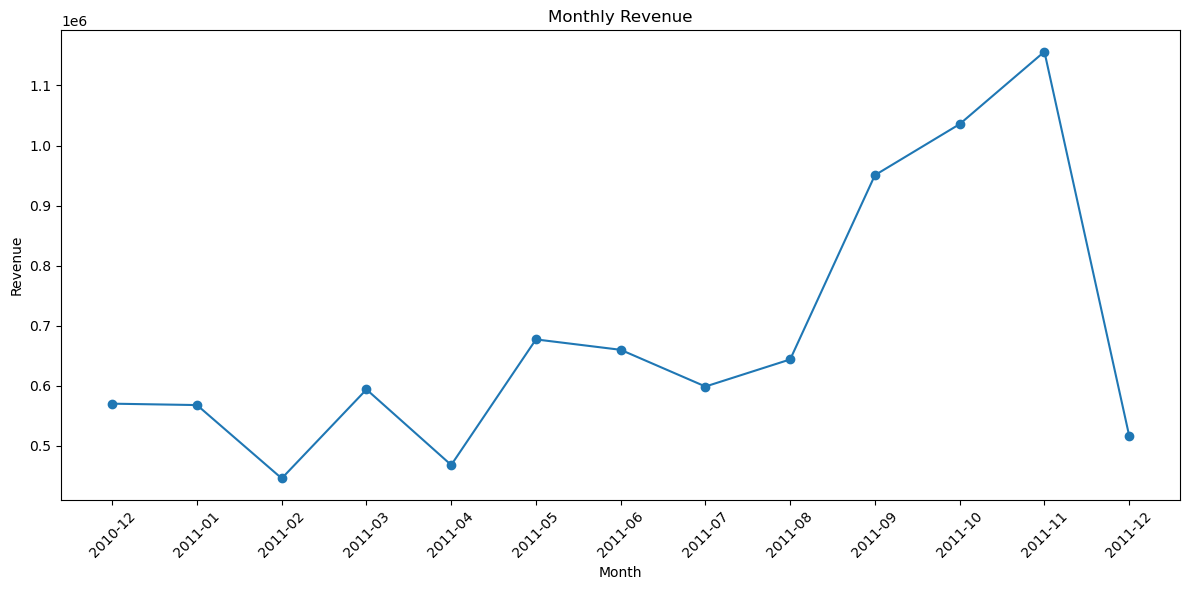

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"].astype(str),
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
#Top 10 products by Revenue 
top_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

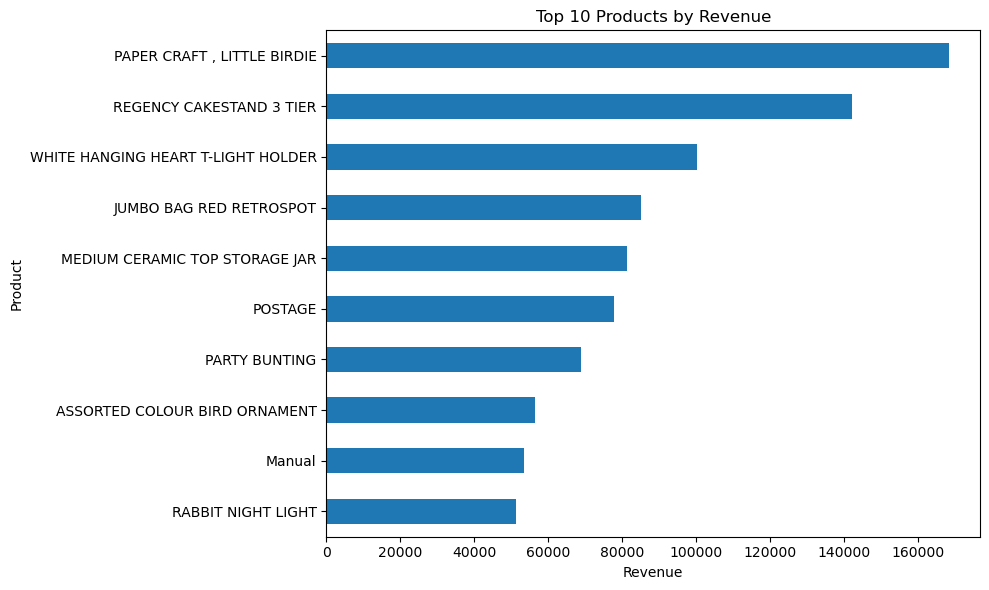

In [33]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [34]:
#products that sell the most units
top_selling_products = (
    clean_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_selling_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

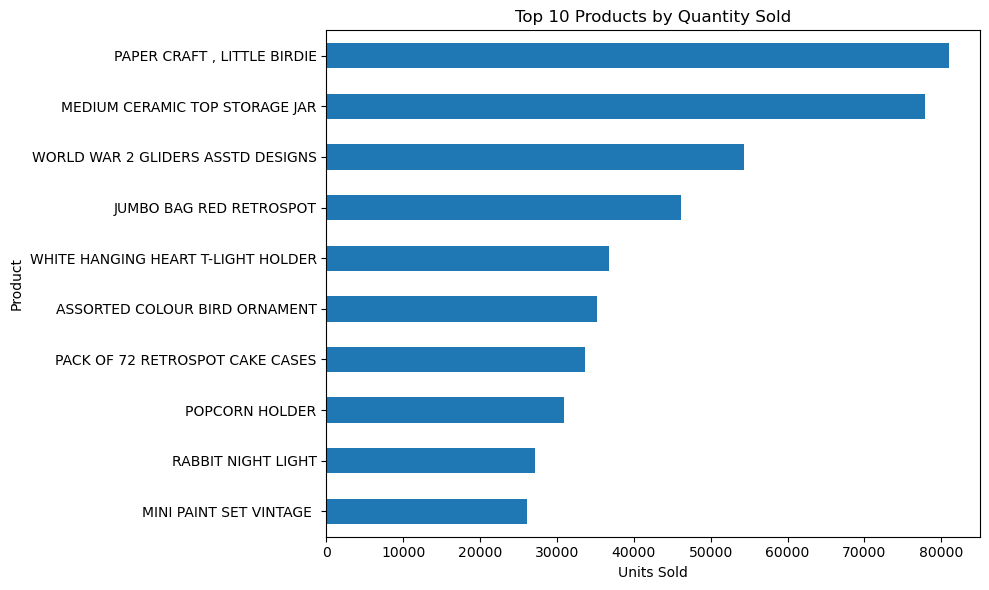

In [35]:
plt.figure(figsize=(10, 6))

top_selling_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [36]:
#customer stats
customer_summary = (
    clean_df.groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalItems=("Quantity", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

customer_summary.head(10)

,TotalRevenue,TotalOrders,TotalItems
CustomerID,,,
14646.0,280206.02,73,196915
18102.0,259657.30,60,64124
17450.0,194390.79,46,69973
16446.0,168472.50,2,80997
14911.0,143711.17,201,80240
12415.0,124914.53,21,77374
14156.0,117210.08,55,57768
17511.0,91062.38,31,64549
16029.0,80850.84,63,40108


In [37]:
top_customers = customer_summary.head(10)

top_customers

,TotalRevenue,TotalOrders,TotalItems
CustomerID,,,
14646.0,280206.02,73,196915
18102.0,259657.30,60,64124
17450.0,194390.79,46,69973
16446.0,168472.50,2,80997
14911.0,143711.17,201,80240
12415.0,124914.53,21,77374
14156.0,117210.08,55,57768
17511.0,91062.38,31,64549
16029.0,80850.84,63,40108


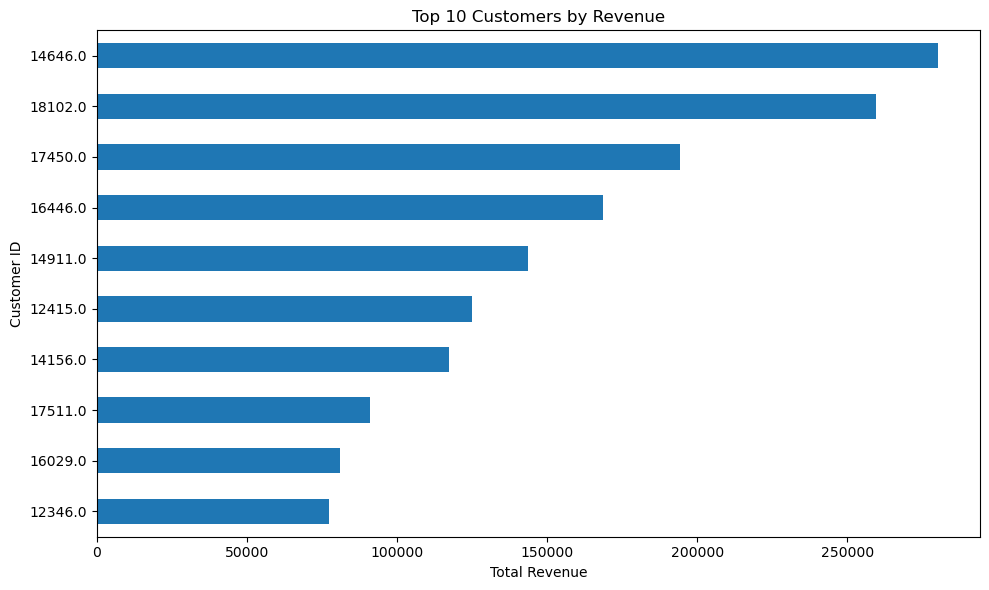

In [38]:
plt.figure(figsize=(10, 6))

top_customers["TotalRevenue"].sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [39]:
customer_summary["TotalRevenue"].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalRevenue, dtype: float64

# RFM

In [40]:
reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [41]:
rfm = (
    clean_df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x:
                 (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [42]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


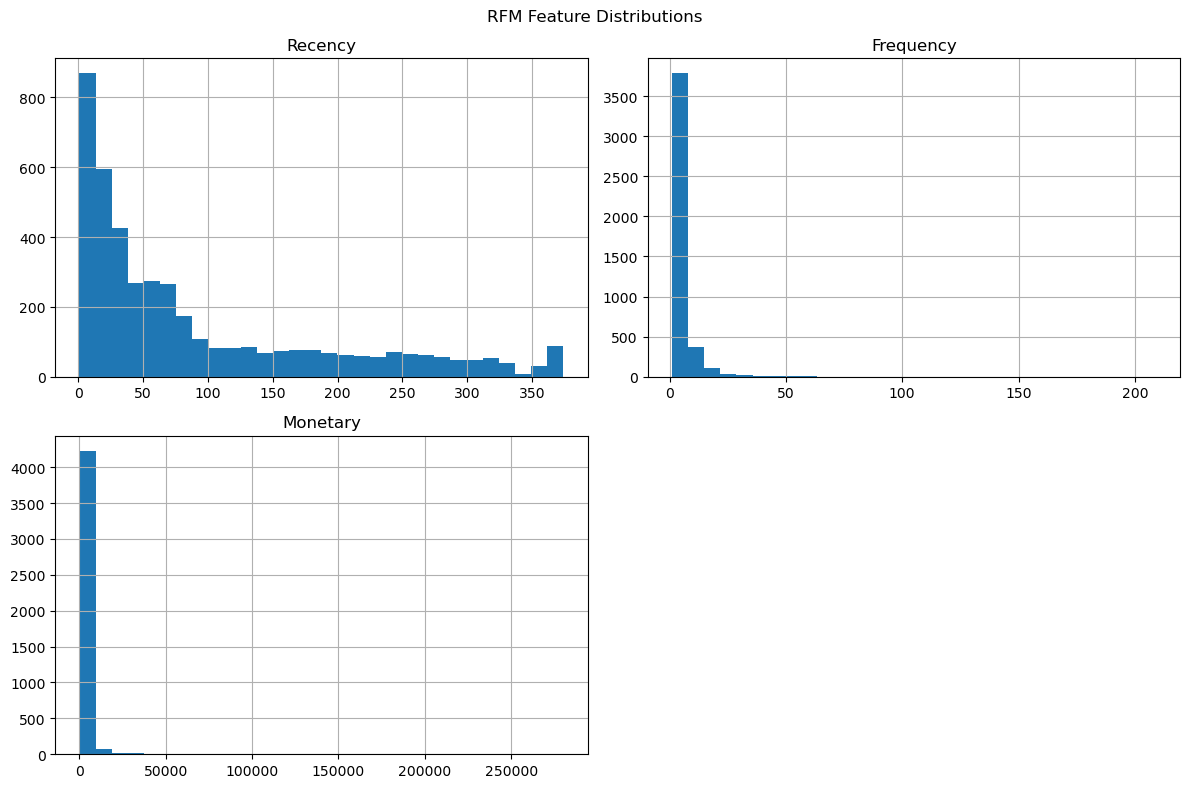

In [43]:
rfm.hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("RFM Feature Distributions")
plt.tight_layout()
plt.show()

In [44]:
import numpy as np

rfm_log = np.log1p(rfm)

In [45]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


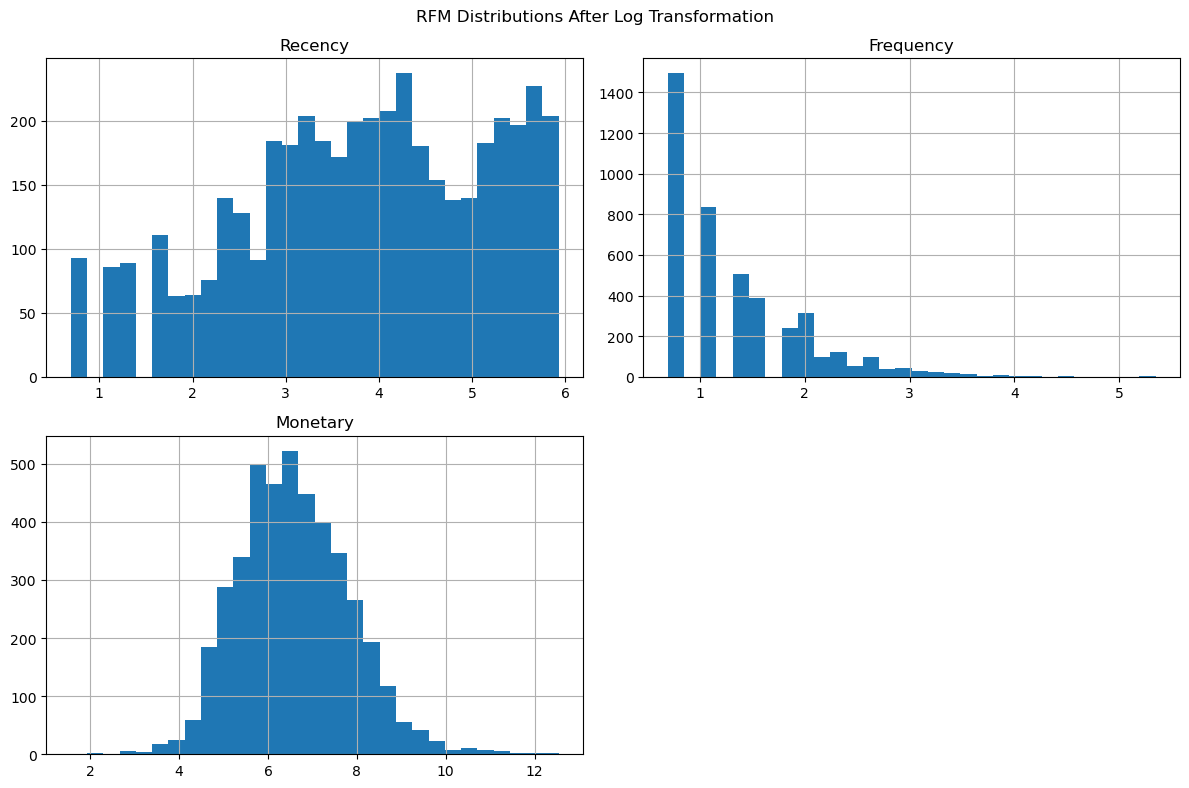

In [46]:
rfm_log.hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("RFM Distributions After Log Transformation")
plt.tight_layout()
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [48]:
rfm_scaled.shape

(4338, 3)

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

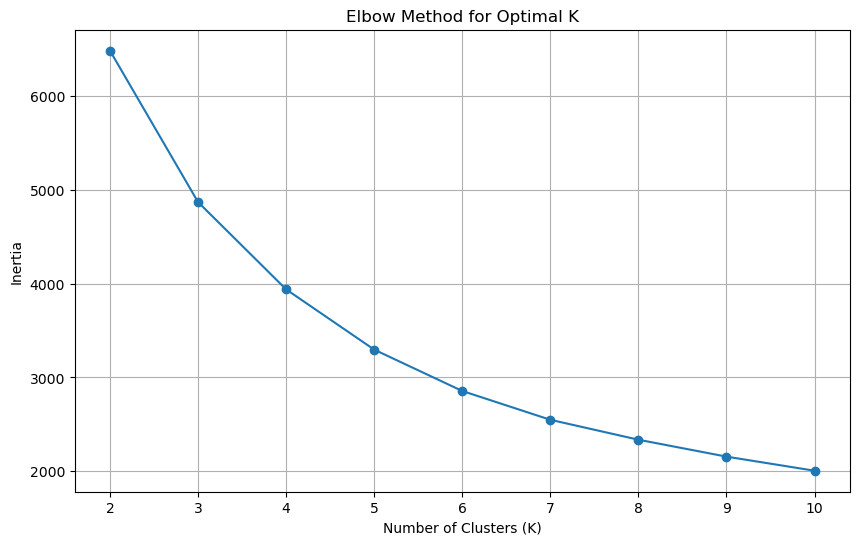

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [51]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 7), silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.3f}")

K=2: Silhouette Score = 0.433
K=3: Silhouette Score = 0.337
K=4: Silhouette Score = 0.338
K=5: Silhouette Score = 0.316
K=6: Silhouette Score = 0.312


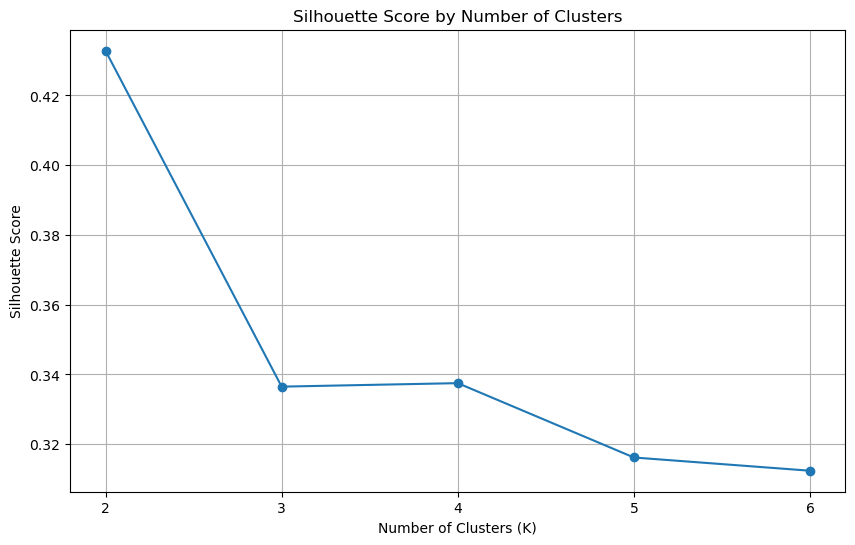

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 7),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 7))
plt.grid(True)

plt.show()

In [53]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm["Cluster_2"] = kmeans_2.fit_predict(rfm_scaled)

In [54]:
cluster_2 = (
    rfm.groupby("Cluster_2")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
)

cluster_2

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster_2,,,,,
0,2672,134.091317,1.671033,495.594945,1324229.693
1,1666,25.888956,8.443577,4539.603362,7562979.201


In [55]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster_4"] = kmeans_4.fit_predict(rfm_scaled)

In [56]:
cluster_4 = (
    rfm.groupby("Cluster_4")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
)

cluster_4

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster_4,,,,,
0,713,12.171108,13.751753,8088.018331,5766757.070
1,1622,181.506782,1.316893,340.998626,553099.771
2,837,17.698925,2.192354,557.322616,466479.030
3,1166,71.635506,4.078902,1801.777893,2100873.023


In [57]:
cluster_names = {
    0: "Champions",
    1: "At Risk",
    2: "Recent Customers",
    3: "Regular Customers"
}

rfm["Segment"] = rfm["Cluster_4"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster_2,Cluster_4,Segment
CustomerID,,,,,,
12346.0,326,1,77183.60,1,3,Regular Customers
12347.0,2,7,4310.00,1,0,Champions
12348.0,75,4,1797.24,1,3,Regular Customers
12349.0,19,1,1757.55,0,2,Recent Customers
12350.0,310,1,334.40,0,1,At Risk


In [58]:
rfm["Segment"].value_counts()

Segment
At Risk              1622
Regular Customers    1166
Recent Customers      837
Champions             713
Name: count, dtype: int64

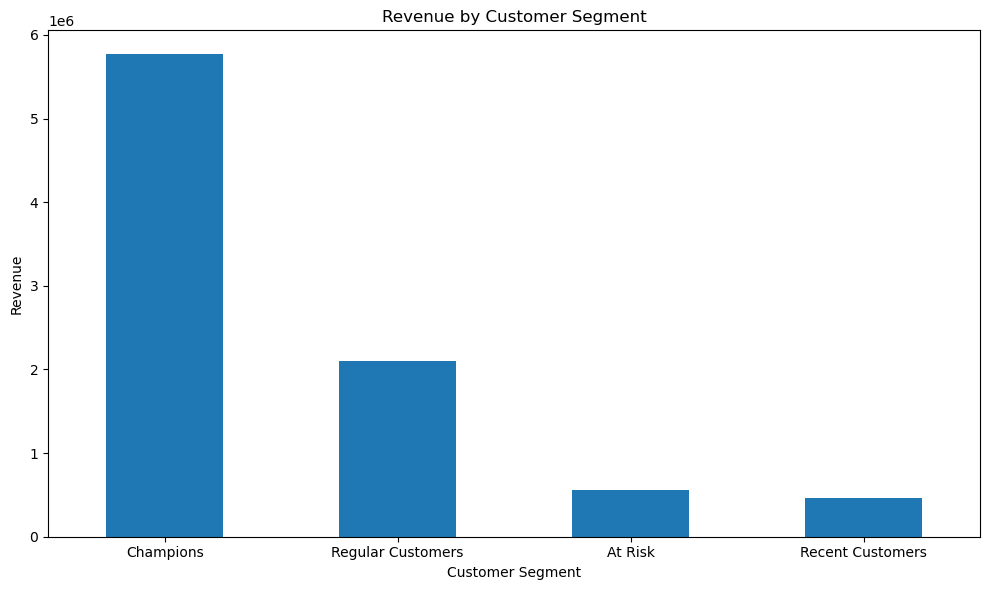

In [59]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

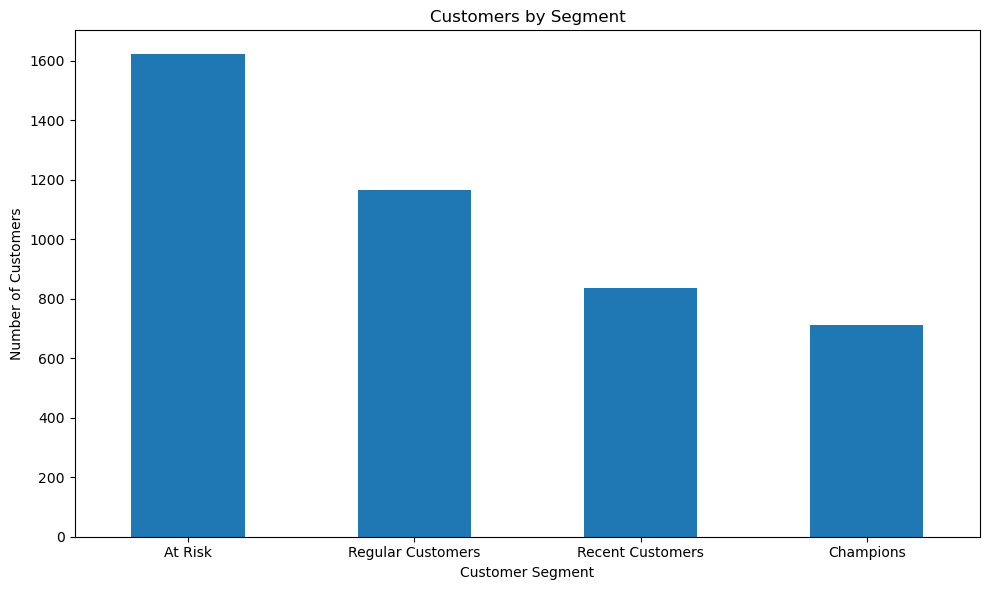

In [60]:
segment_customers = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))

segment_customers.plot(kind="bar")

plt.title("Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# cluster plot

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

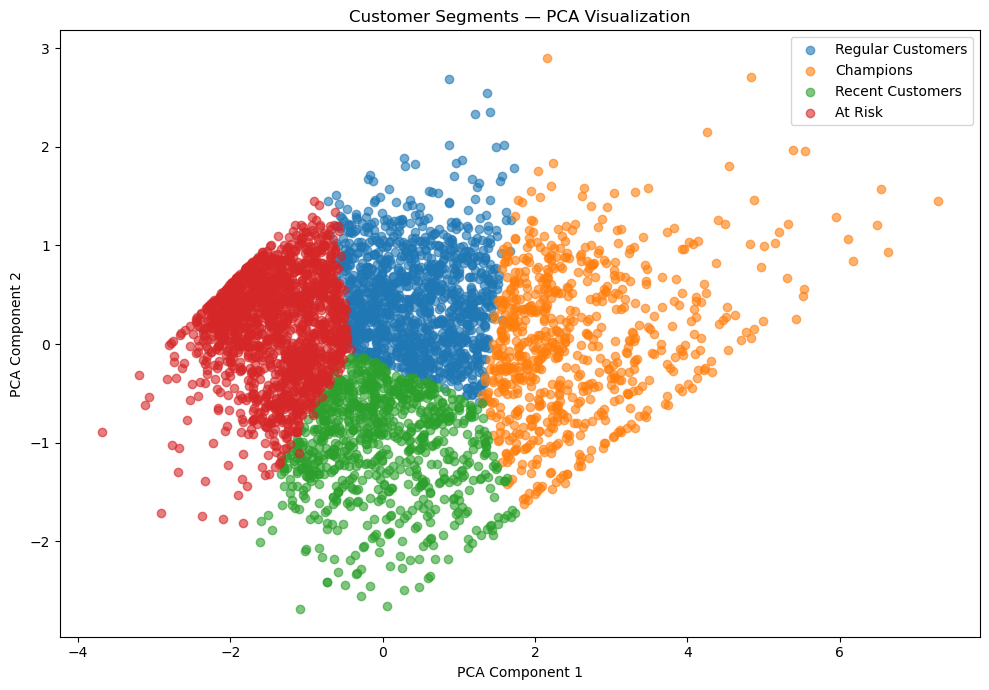

In [62]:
plt.figure(figsize=(10, 7))

for segment in rfm["Segment"].unique():
    segment_data = rfm[rfm["Segment"] == segment]
    
    plt.scatter(
        segment_data["PCA1"],
        segment_data["PCA2"],
        label=segment,
        alpha=0.6
    )

plt.title("Customer Segments — PCA Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Champions,713,12.171108,13.751753,8088.018331,5766757.070
Regular Customers,1166,71.635506,4.078902,1801.777893,2100873.023
At Risk,1622,181.506782,1.316893,340.998626,553099.771
Recent Customers,837,17.698925,2.192354,557.322616,466479.030


In [64]:
segment_summary["Revenue_Share"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share
Segment,,,,,,
Champions,713,12.171108,13.751753,8088.018331,5766757.070,64.888281
Regular Customers,1166,71.635506,4.078902,1801.777893,2100873.023,23.639289
At Risk,1622,181.506782,1.316893,340.998626,553099.771,6.223549
Recent Customers,837,17.698925,2.192354,557.322616,466479.030,5.248881


# AI Part

In [65]:
ai_summary = segment_summary.round(2).reset_index()

ai_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share
0,Champions,713,12.17,13.75,8088.02,5766757.07,64.89
1,Regular Customers,1166,71.64,4.08,1801.78,2100873.02,23.64
2,At Risk,1622,181.51,1.32,341.00,553099.77,6.22
3,Recent Customers,837,17.70,2.19,557.32,466479.03,5.25


In [66]:
business_context = f"""
We analyzed an online retail dataset containing {len(rfm):,} customers.

Customer segmentation was performed using RFM analysis:
- Recency: days since the customer's most recent purchase
- Frequency: number of unique orders
- Monetary: total customer revenue

We used log transformation and standardization before K-Means clustering.
Four clusters were selected based on a combination of the Elbow Method,
Silhouette Score, and business interpretability.

Segment summary:

{ai_summary.to_string(index=False)}

Important interpretation:
- Lower Recency means more recently active.
- Higher Frequency means more repeat purchases.
- Higher Monetary means greater customer value.

The goal is to identify customer segments and recommend practical
business strategies for retention, reactivation, and growth.
"""

print(business_context)


We analyzed an online retail dataset containing 4,338 customers.

Customer segmentation was performed using RFM analysis:
- Recency: days since the customer's most recent purchase
- Frequency: number of unique orders
- Monetary: total customer revenue

We used log transformation and standardization before K-Means clustering.
Four clusters were selected based on a combination of the Elbow Method,
Silhouette Score, and business interpretability.

Segment summary:

          Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share
        Champions        713        12.17          13.75       8088.02     5766757.07          64.89
Regular Customers       1166        71.64           4.08       1801.78     2100873.02          23.64
          At Risk       1622       181.51           1.32        341.00      553099.77           6.22
 Recent Customers        837        17.70           2.19        557.32      466479.03           5.25

Important interpretation:


In [76]:
!pip install -U google-genai

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached websockets-16.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.2 MB/s  0:00:00m 1.8 MB/s eta 0:00:01
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.8 MB/s  0:00:012.0 MB/s eta 0:00:01:01
Using cached websockets-16.1.1-cp313-cp313-macosx_11_0_arm64.whl (177 kB)
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydantic-2.12.4:
      Successfully uninstalled pydantic-2.12.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [google-genai]0m 4/5 [google-genai]


In [77]:
import os
from getpass import getpass

gemini_key = getpass("Enter your Gemini API key: ")

os.environ["GEMINI_API_KEY"] = gemini_key

print("Gemini API key loaded:", bool(os.getenv("GEMINI_API_KEY")))

Enter your Gemini API key:  ········


Gemini API key loaded: True


In [78]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

print("Gemini client created successfully!")

Gemini client created successfully!


In [79]:
response = client.models.generate_content(
    model="gemini-3.7-flash",
    contents="Reply with exactly: Customer AI connection successful!"
)

print(response.text)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Customer AI connection successful!


In [81]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="Reply with exactly: RFM AI analysis is working!"
)

print(response.text)

RFM AI analysis is working!


In [82]:
prompt = f"""
You are an expert customer analytics consultant.

Analyze these customer segmentation results from an online retail dataset.

{ai_summary.to_string(index=False)}

Definitions:
- Recency = days since the customer's most recent purchase. Lower is better.
- Frequency = number of unique orders. Higher is better.
- Monetary = total customer revenue. Higher is better.

Provide:

1. The most important business insight.
2. Which segment should be prioritized and why.
3. A retention strategy for Champions.
4. A reactivation strategy for At Risk customers.
5. A growth strategy for Recent Customers.
6. A strategy for Regular Customers.
7. One overall business recommendation.

Rules:
- Use only the statistics provided.
- Do not invent numbers.
- Clearly separate observations from recommendations.
- Keep the answer practical and concise.
"""

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response.text)

Here is the customer segmentation analysis based on the provided dataset.

---

### 1. The Most Important Business Insight
* **Observation:** Revenue is heavily concentrated in a tiny fraction of the customer base. Champions account for **64.89%** ($5,766,757.07) of total revenue, despite representing only 713 customers. Conversely, the largest segment by customer headcount (At Risk: 1,622 customers) contributes only **6.22%** ($553,099.77) of revenue.
* **Recommendation:** Focus organizational resources on high-value customer retention and migration rather than equal-effort treatment across all customer segments.

---

### 2. Segment Priority
* **Observation:** Champions yield an average monetary value of **$8,088.02** with an average frequency of **13.75** orders and recency of **12.17 days**.
* **Recommendation:** **Prioritize the Champions segment.** Losing even a small percentage of Champions will drastically impact revenue, as their individual value ($8,088.02) is over 23 times h

In [83]:
prompt = f"""
You are an expert customer analytics consultant.

We analyzed an online retail dataset containing 4,338 customers.

The customers were segmented using:
- RFM analysis
- Log transformation
- StandardScaler
- K-Means clustering
- PCA for visualization

Here is the final segment summary:

{ai_summary.to_string(index=False)}

Definitions:
- Recency = days since the customer's most recent purchase. Lower is better.
- Frequency = number of unique orders. Higher is better.
- Monetary = total revenue generated by the customer. Higher is better.

Analyze the results and provide:

1. The single most important business insight.
2. Which customer segment should be prioritized and why?
3. A retention strategy for Champions.
4. A reactivation strategy for At Risk customers.
5. A growth strategy for Recent Customers.
6. A strategy for Regular Customers.
7. Three concrete actions the business should take next.

IMPORTANT:
- Use the actual numbers provided.
- Do not invent statistics.
- Clearly separate observations from recommendations.
- Keep the response practical.
"""

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response.text)

Here is the strategic analysis and actionable roadmap based on your RFM segmentation results.

---

### 1. The Single Most Important Business Insight

* **Observations:** 
  * The **Champions** segment accounts for **16.43% of all customers** (713 out of 4,338) but drives **64.89% ($5,766,757.07)** of total revenue.
  * The **At Risk** segment is the largest customer group (**1,622 customers; 37.39%** of the base) but generates only **6.22% ($553,099.77)** of total revenue.
* **Strategic Insight:** 
  * The business suffers from **extreme revenue concentration risk**. Nearly two-thirds of all revenue relies on a small core of 713 buyers. While losing an At Risk customer has minimal financial impact ($341.00 avg spend), losing a single Champion ($8,088.02 avg spend) equals losing **23.7 At Risk customers**. Protecting top buyers is far more critical to bottom-line stability than trying to revive cold leads.

---

### 2. Segment Prioritization & Rationale

#### **Priority Segment: Champi

In [84]:
final_summary = segment_summary.copy()

final_summary = final_summary.reset_index()

final_summary["Revenue_Share"] = final_summary["Revenue_Share"].round(2)
final_summary["Avg_Recency"] = final_summary["Avg_Recency"].round(2)
final_summary["Avg_Frequency"] = final_summary["Avg_Frequency"].round(2)
final_summary["Avg_Monetary"] = final_summary["Avg_Monetary"].round(2)
final_summary["Total_Revenue"] = final_summary["Total_Revenue"].round(2)

final_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share
0,Champions,713,12.17,13.75,8088.02,5766757.07,64.89
1,Regular Customers,1166,71.64,4.08,1801.78,2100873.02,23.64
2,At Risk,1622,181.51,1.32,341.00,553099.77,6.22
3,Recent Customers,837,17.70,2.19,557.32,466479.03,5.25


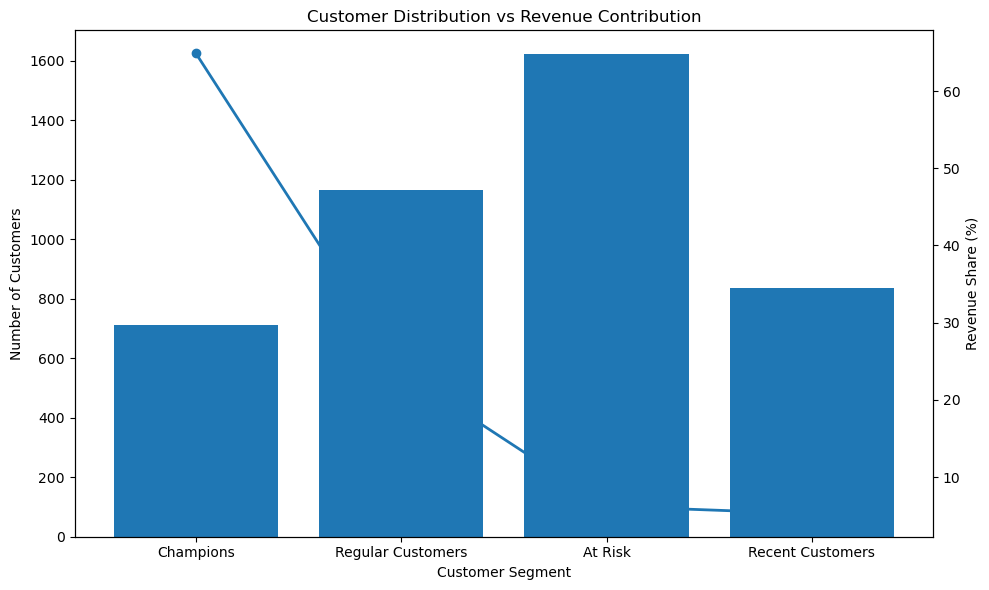

In [85]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

x = final_summary["Segment"]

bars = ax1.bar(
    x,
    final_summary["Customers"]
)

ax1.set_ylabel("Number of Customers")
ax1.set_xlabel("Customer Segment")
ax1.set_title("Customer Distribution vs Revenue Contribution")

ax2 = ax1.twinx()

ax2.plot(
    x,
    final_summary["Revenue_Share"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Revenue Share (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [86]:
champion_revenue_share = (
    final_summary.loc[
        final_summary["Segment"] == "Champions",
        "Revenue_Share"
    ].iloc[0]
)

champion_customer_share = (
    final_summary.loc[
        final_summary["Segment"] == "Champions",
        "Customers"
    ].iloc[0]
    / len(rfm)
    * 100
)

print(f"Champions represent {champion_customer_share:.2f}% of customers.")
print(f"Champions generate {champion_revenue_share:.2f}% of revenue.")

Champions represent 16.44% of customers.
Champions generate 64.89% of revenue.


In [88]:
#ai insight function 
def ask_gemini(question):

    prompt = f"""
You are an AI customer analytics assistant.

Here is the customer segmentation data:

{ai_summary.to_string(index=False)}

Customer segments:
- Champions = highly recent, frequent and high-value customers
- Regular Customers = established repeat customers
- Recent Customers = recently active but lower frequency/value
- At Risk = customers with high recency and low frequency/value

Answer the user's question using ONLY the provided data.

If you make a recommendation that is not directly supported by the data,
clearly label it as a recommendation.

User question:
{question}
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    return response.text

In [89]:
print(
    ask_gemini(
        "Which customer segment is most important to the business and why?"
    )
)

Based on the provided data, the **Champions** segment is the most important to the business. 

Here is why:

* **Majority Revenue Contribution:** The Champions segment generates **$5,766,757.07**, representing **64.89%** (nearly two-thirds) of the company's total revenue, despite making up only 713 customers.
* **Highest Average Monetary Value:** They spend significantly more per customer than any other segment, with an average monetary value of **$8,088.02** (compared to $1,801.78 for Regular Customers, $557.32 for Recent Customers, and $341.00 for At Risk customers).
* **Highest Engagement:** They buy most frequently, with an average frequency of **13.75** purchases.
* **Most Recently Active:** They have the lowest average recency score of **12.17**, meaning they have purchased most recently compared to the other segments.

***

**Recommendation:** 
*(Note: The following strategy is a recommendation based on business logic and is not explicitly detailed in the raw data)*

The primary

In [90]:
print(
    ask_gemini(
        "What should the business do about At Risk customers?"
    )
)

Based on the provided data, here is the profile of the **At Risk** segment:

* **Customer Count:** 1,622 (the largest segment by volume)
* **Average Recency:** 181.51 days/units (the longest time since last purchase)
* **Average Frequency:** 1.32 purchases
* **Average Monetary Value:** $341.00
* **Total Revenue:** $553,099.77 (6.22% of total revenue)

---

### **Recommendations for the Business**

*(Note: The following action steps are recommendations based on analyzing the metrics above).*

1. **Launch Targeted Win-Back Campaigns:**
   * **Recommendation:** Since these customers haven't purchased in a long time (Avg_Recency = 181.51) and have bought mostly once (Avg_Frequency = 1.32), send re-engagement emails with special incentives, discounts, or "We miss you" offers to encourage a second or return purchase.

2. **Conduct Churn Research:**
   * **Recommendation:** Survey a sample of these 1,622 customers to understand why they stopped purchasing after 1–2 orders (e.g., product satis

In [91]:
import os

os.makedirs("../data/processed", exist_ok=True)

rfm.to_csv("../data/processed/rfm_customers.csv", index=False)
segment_summary.to_csv("../data/processed/segment_summary.csv")

print("Files exported successfully!")

Files exported successfully!
